## Análisis de Datos Meteorológicos con una API Pública
Obtener datos del clima de una ciudad usando la API de Open-Meteo (https://open-meteo.com/) y mostrar el pronóstico para Bilbao.

* Haz una petición a la API para que devuelva el pronóstico de las temperaturas para una semana en Bilbao. Tip: el parámetro correspondiente en el query es `temperature_2m` además de la latitud y la longitud.
* Procesa la respuesta en formato JSON para obtener dos listas: una con la lista de temperaturas y otra con las fechas-horas correspondientes.
* Crea un DataFrame con esas dos columnas: `Hora` y `Temperatura`
* Elige la gráfica adecuada y visualiza el pronóstico de temperaturas.

Para crear la variable `Hora` del DataFrame puedes introducir directamente la lista que se obtiene del campo `data["hourly"]["time"]` o procesar esa lista mediante el siguiente código:

`hours = pd.date_range(start=lista_de_horas, periods=len(temps), freq="H")`

In [1]:
import requests # me permite hacer peticiones HTTP a servidores web
import pandas as pd
import matplotlib.pyplot as plt

# Coordenadas de Kuna en Bilbao
latitude = 43.2540
longitude = -2.9230

# contruccion de la url y petición a la API:
url = f"https://api.open-meteo.com/v1/forecast?"  # Aquí vienen el resto de los parámetros

In [2]:
# creo un d iccionario con los parámetros de la consulta

parametros = {
    "latitude": latitude,
    "longitude": longitude,
    "hourly": "temperature_2m", # variable: temp a 2 m
    "forecast_days": 7 # num días de pronóstico
}

respuesta = requests.get(url, params=parametros) # realizo petición http, el servidor la procesa y devuelve una respuesta

respuesta

<Response [200]>

In [3]:
# procesamiento de la respuesta json:
datos = respuesta.json() # convierto la respuesta a formato JSON


# exploración de la estructura de datos:
for clave in datos.keys(): # miramos las claves del json
    print(f"   - {clave}")
print()


# extracción de las temperaturas y fechas:
lista_fechas = datos["hourly"]["time"] # accedo a los datos horarios dentro del json
lista_temperaturas = datos["hourly"]["temperature_2m"] # la estructura es: datos -> hourly -> time / temperature_2m


# información de los datos obtenidos:
print(f"Num total de registros: {len(lista_temperaturas)} horas.")
print(f"Primera fecha: {lista_fechas[0]}.")
print(f"Última fecha: {lista_fechas[-1]}.")
print()
print(f"Temperatura mínima: {min(lista_temperaturas)}°C.")
print(f"Temperatura máxima: {max(lista_temperaturas)}°C.")
print(f"Temperatura media: {sum(lista_temperaturas)/len(lista_temperaturas):.2f}°C.")
print()


for i in range(5): # muestro los priemros 5 valores como ejemplo
    print(f"{lista_fechas[i]} -> {lista_temperaturas[i]}°C.")

   - latitude
   - longitude
   - generationtime_ms
   - utc_offset_seconds
   - timezone
   - timezone_abbreviation
   - elevation
   - hourly_units
   - hourly

Num total de registros: 168 horas.
Primera fecha: 2026-03-26T00:00.
Última fecha: 2026-04-01T23:00.

Temperatura mínima: 6.3°C.
Temperatura máxima: 15.5°C.
Temperatura media: 10.69°C.

2026-03-26T00:00 -> 10.6°C.
2026-03-26T01:00 -> 10.2°C.
2026-03-26T02:00 -> 9.9°C.
2026-03-26T03:00 -> 9.1°C.
2026-03-26T04:00 -> 9.4°C.


In [4]:
# creo el dataframe (dos cols: hora y temperatura):

df = pd.DataFrame({"Hora": pd.to_datetime(lista_fechas),"Temperatura": lista_temperaturas})

df

,Hora,Temperatura
0,2026-03-26 00:00:00,10.6
1,2026-03-26 01:00:00,10.2
2,2026-03-26 02:00:00,9.9
3,2026-03-26 03:00:00,9.1
4,2026-03-26 04:00:00,9.4
...,...,...
163,2026-04-01 19:00:00,12.5
164,2026-04-01 20:00:00,11.8
165,2026-04-01 21:00:00,11.2
166,2026-04-01 22:00:00,10.9


In [5]:
df.head()

,Hora,Temperatura
0,2026-03-26 00:00:00,10.6
1,2026-03-26 01:00:00,10.2
2,2026-03-26 02:00:00,9.9
3,2026-03-26 03:00:00,9.1
4,2026-03-26 04:00:00,9.4


In [6]:
df.tail()

,Hora,Temperatura
163,2026-04-01 19:00:00,12.5
164,2026-04-01 20:00:00,11.8
165,2026-04-01 21:00:00,11.2
166,2026-04-01 22:00:00,10.9
167,2026-04-01 23:00:00,10.8


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Hora         168 non-null    datetime64[us]
 1   Temperatura  168 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 2.8 KB


In [8]:
df.shape[0]

168

In [9]:
df.shape[1]

2

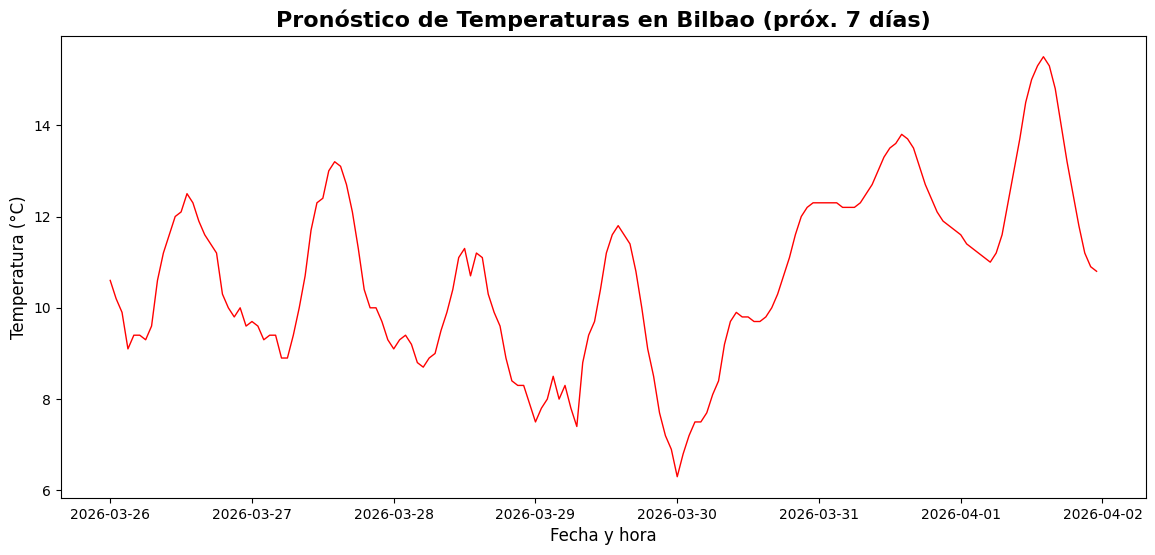

In [10]:
# gráfica

plt.figure(figsize=(14, 6))

# dibujo linea temp:
plt.plot(df["Hora"], 
         df["Temperatura"], 
         marker="", 
         linewidth=1, 
         color="red", 
         label="Temperatura")


plt.title("Pronóstico de Temperaturas en Bilbao (próx. 7 días)", 
          fontsize=16, 
          fontweight="bold")

plt.xlabel("Fecha y hora", fontsize=12) # eje x
plt.ylabel("Temperatura (°C)", fontsize=12) # eje y


# plt.legend() # en verdad esto no hace falta

plt.show()